In [212]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
internal_PDC_VS_MPC_dir = os.getcwd()
internal_March_27_2026_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..'))
print(f'The current working directory is : {internal_PDC_VS_MPC_dir}')
internal_MPC_data_dir = os.path.abspath(os.path.join(internal_March_27_2026_dir, 'March27_2026'))
print(f'The MPC data directory : {internal_MPC_data_dir}')
internal_PD_data_dir = os.path.abspath(os.path.join(internal_March_27_2026_dir, 'March27_2026'))
print(f'The PD data directory : {internal_PD_data_dir}')
internal_VTR_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..', '..'))
print(f'The VTR directory : {internal_VTR_dir}')
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
print(f'The root directory : {root_dir}')
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
print(f'The internal HT directory : {internal_HT_dir}')
internal_HT_MPC_dir = os.path.abspath(os.path.join(internal_HT_dir, '2_MPC_Controllers'))
print(f'The internal HT MPC directory : {internal_HT_MPC_dir}')
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_MPC_dir, 'scripts'))
print(f'The internal scripts directory : {internal_scripts_dir}')
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

The current working directory is : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026
The PD data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026
The VTR directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results
The root directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control
The internal HT directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\8_Hardware\Hardware_Testing
The internal HT MPC directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adapti

In [213]:
internal_PDC_CDP_data_dir = os.path.abspath(os.path.join(internal_PD_data_dir, 'Processed_Data_March27_PD'))
internal_MPC_CDP_data_dir = os.path.abspath(os.path.join(internal_MPC_data_dir, 'Processed_Data_March27_MPC'))
print(f'The PDC data directory : {internal_PDC_CDP_data_dir}')
print(f'The MPC data directory : {internal_MPC_CDP_data_dir}')

The PDC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026\Processed_Data_March27_PD
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026\Processed_Data_March27_MPC


In [214]:
# Print the names of the files in the PDC and MPC data directories to check if they are the same
print(f'PDC data files : {os.listdir(internal_PDC_CDP_data_dir)}')
print(f'MPC data files : {os.listdir(internal_MPC_CDP_data_dir)}')   
      

PDC data files : ['Data_Mar27_PD_10kph_CS1.csv', 'Data_Mar27_PD_10kph_CS2.csv', 'Data_Mar27_PD_10kph_CS3.csv', 'Data_Mar27_PD_5kph_CS1.csv', 'Data_Mar27_PD_5kph_CS2.csv', 'Data_Mar27_PD_5kph_CS3.csv']
MPC data files : ['Data_Mar27_MPC_10kph_CS1.csv', 'Data_Mar27_MPC_10kph_CS2.csv', 'Data_Mar27_MPC_10kph_CS3.csv', 'Data_Mar27_MPC_5kph_CS1.csv', 'Data_Mar27_MPC_5kph_CS2.csv', 'Data_Mar27_MPC_5kph_CS3.csv', 'Data_Mar27_MPC_5kph_CS4.csv']


In [215]:
PDC_data_list = []
for i in range(len(os.listdir(internal_PDC_CDP_data_dir))):
    PDC_data_list.append(pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, os.listdir(internal_PDC_CDP_data_dir)[i])))
    
MPC_data_list = []
for i in range(len(os.listdir(internal_MPC_CDP_data_dir))):
    MPC_data_list.append(pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, os.listdir(internal_MPC_CDP_data_dir)[i])))

In [216]:
# Print the column names of the first dataframe in PDC_data_list and MPC_data_list to check if they are the same
print(f'PDC data columns : {PDC_data_list[0].columns}')
print(f'MPC data columns : {MPC_data_list[0].columns}')

PDC data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)',
       'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)',
       'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph',
       'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean',
       'Ego_Position_clean', 'Obs_Position_clean'],
      dtype='object')
MPC data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)',
       'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)',
       'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph',
       'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean',
       'Ego_Acceleration_clean', 'Obs_Acceleration_cle

## For 5Kmph

In [217]:
# Selecting the file name for both PDC and MPC to plot them together.
PDC_file_name = os.listdir(internal_PDC_CDP_data_dir)[4]    
MPC_file_name = os.listdir(internal_MPC_CDP_data_dir)[6]
print(f'Selected PDC file name : {PDC_file_name}')
print(f'Selected MPC file name : {MPC_file_name}')

Selected PDC file name : Data_Mar27_PD_5kph_CS2.csv
Selected MPC file name : Data_Mar27_MPC_5kph_CS4.csv


PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Acceleration_clean', 'Obs_Acceleration_clean', 'Ego_Position_clean', 'Obs_Position_clean']


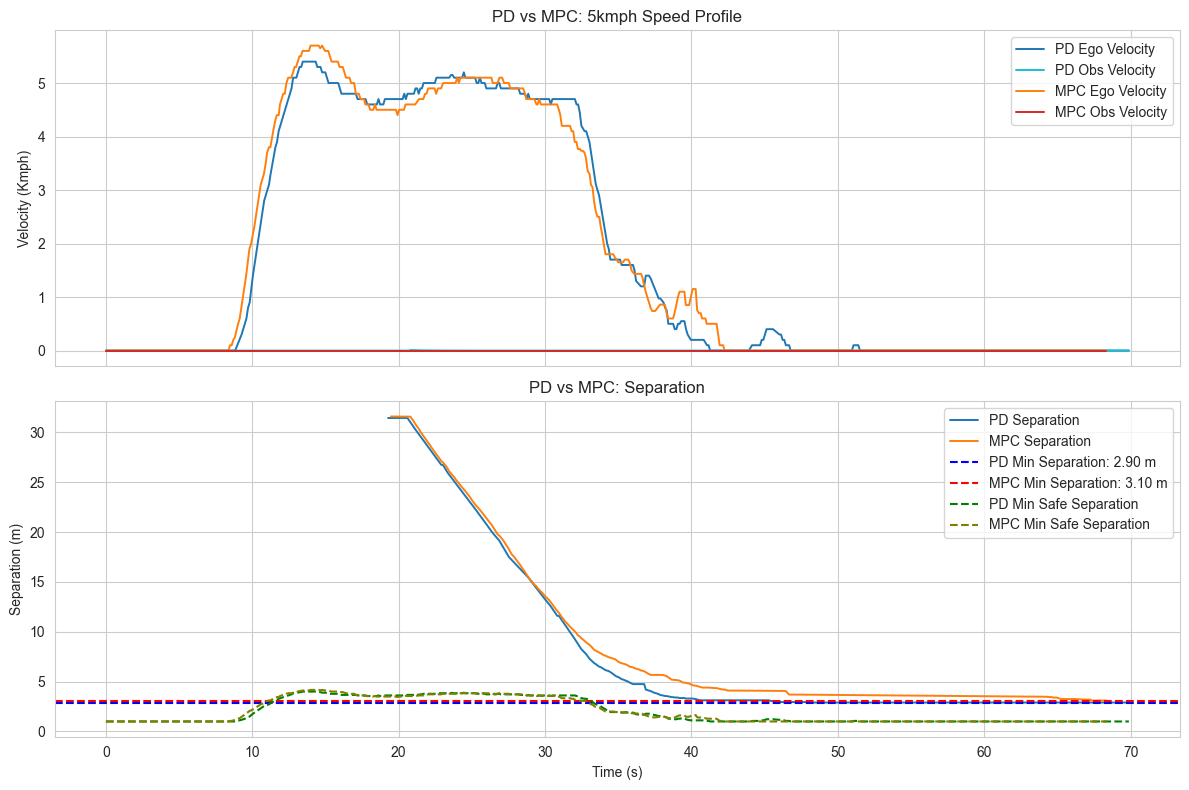

In [218]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, MPC_file_name))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:cyan", linewidth=1.4)
ax[0].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:orange", linewidth=1.4)
ax[0].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:red", linewidth=1.4)
ax[0].set_ylabel("Velocity (Kmph)")
ax[0].legend(loc="best")
ax[0].grid(True)
ax[0].set_title("PD vs MPC: 5kmph Speed Profile")

# Plot 2: Separation for PD and MPC
ax[1].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:orange", linewidth=1.4)
ax[1].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1].axhline(y=minimum_separation_mpc, color='red', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1].set_ylabel("Separation (m)")
ax[1].set_xlabel("Time (s)")
ax[1].legend(loc="best")
ax[1].grid(True)
ax[1].set_title("PD vs MPC: Separation")

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
legends = ax[1].get_legend_handles_labels()
by_label = dict(zip(legends[1], legends[0]))
ax[1].legend(by_label.values(), by_label.keys(), loc="best")

plt.tight_layout()
plt.show() 

PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Acceleration_clean', 'Obs_Acceleration_clean', 'Ego_Position_clean', 'Obs_Position_clean']


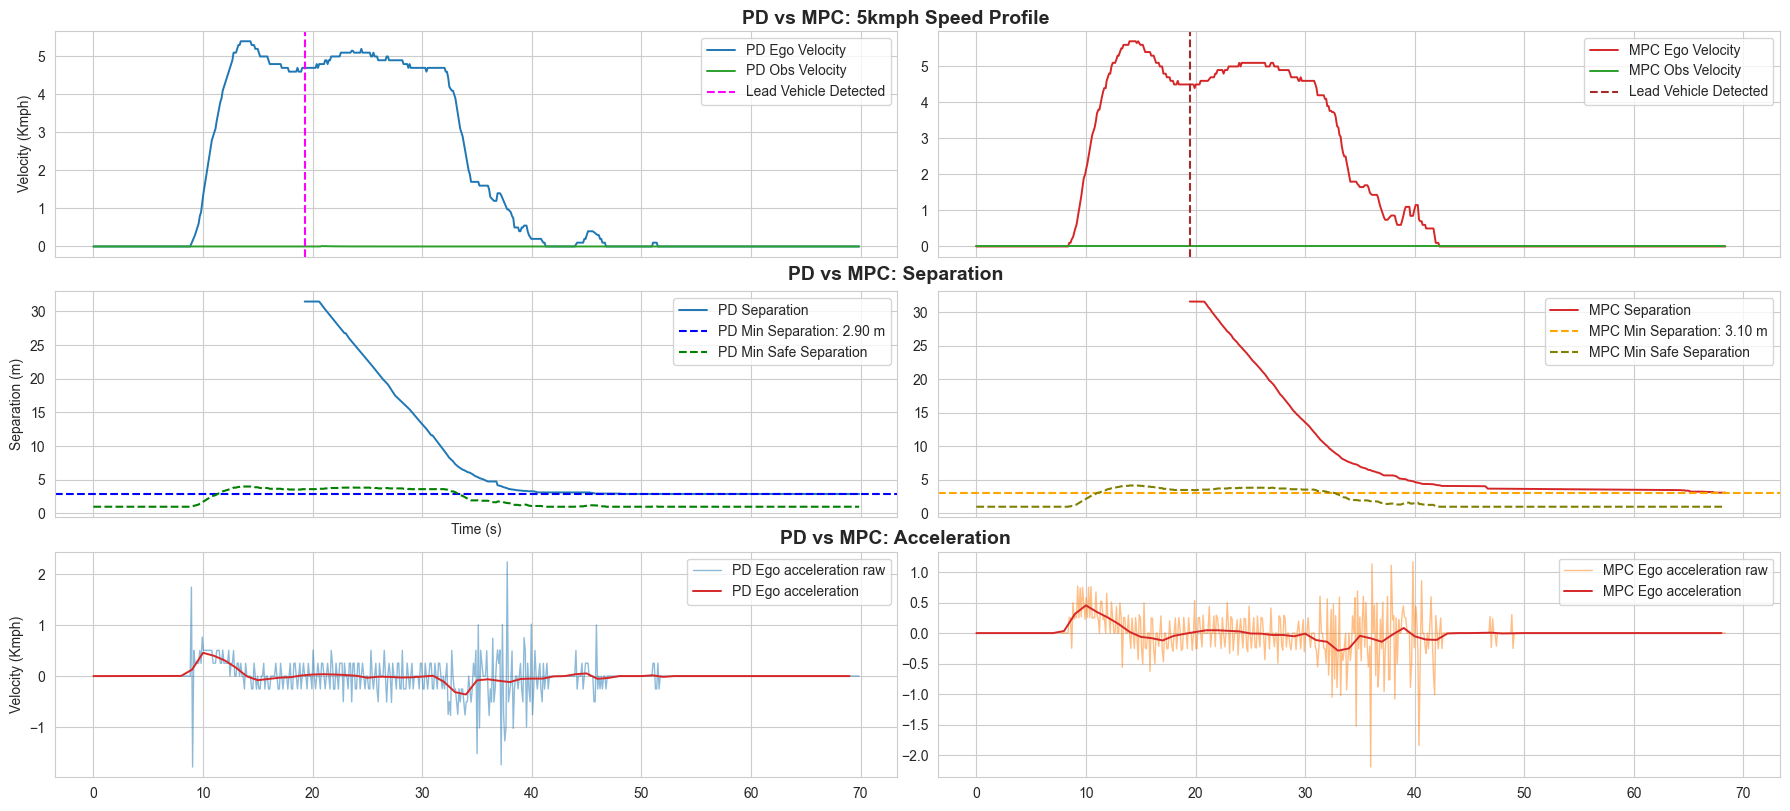

In [219]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, MPC_file_name))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
x_col_1 = "Time_1s" # Time in 1 second
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"
ego_acc_raw = "Ego_Acceleration_raw(m/s^2)"
ego_acc_clean = "Ego_Acceleration(m/s^2)"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(3, 2, figsize=(18, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0][0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0][0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:red", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][0].set_ylabel("Velocity (Kmph)")
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best")
ax[0][0].grid(True)
ax[0][1].grid(True)

# Plot the detection line at the point where the obstacle is detected (when separation starts decreasing from a large value)
detection_time_pd = pdc_df[pdc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
detection_time_mpc = mpc_df[mpc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
ax[0][0].axvline(x=detection_time_pd, color='magenta', linestyle='--', label= 'Lead Vehicle Detected')
ax[0][1].axvline(x=detection_time_mpc, color='brown', linestyle='--', label='Lead Vehicle Detected')
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best") 

# Plot 2: Separation for PD and MPC
ax[1][0].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1][1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:red", linewidth=1.4)
ax[1][0].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1][1].axhline(y=minimum_separation_mpc, color='orange', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1][0].set_ylabel("Separation (m)")
ax[1][0].set_xlabel("Time (s)")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")
ax[1][0].grid(True)
ax[1][1].grid(True)

# Plot 3 : Acceleration for PD and MPC
ax[2][0].plot(pdc_df[x_col], pdc_df[ego_acc_raw], label="PD Ego acceleration raw", color="tab:blue", linewidth=1, alpha=0.5)
ax[2][0].plot(pdc_df[x_col_1], pdc_df[ego_acc_clean], label="PD Ego acceleration ", color="tab:red", linewidth=1.4)
ax[2][1].plot(mpc_df[x_col], mpc_df[ego_acc_raw], label="MPC Ego acceleration raw", color="tab:orange", linewidth=1 , alpha=0.5)
ax[2][1].plot(mpc_df[x_col_1], mpc_df[ego_acc_clean], label="MPC Ego acceleration", color="tab:red", linewidth=1.4)
ax[2][0].set_ylabel("Velocity (Kmph)")
ax[2][0].legend(loc="best")
ax[2][1].legend(loc="best")
ax[2][0].grid(True)
ax[2][1].grid(True)



fig.subplots_adjust(hspace=0.8)  # Reasonable spacing between rows
plt.tight_layout()

fig.text(0.5, 0.99, "PD vs MPC: 5kmph Speed Profile", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.67, "PD vs MPC: Separation", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.34, "PD vs MPC: Acceleration", ha='center', fontsize=14, weight='bold')

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1][0].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1][1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")

plt.show() 

## For 10kmph

In [220]:
# Selecting the file name for both PDC and MPC to plot them together.
PDC_file_name = os.listdir(internal_PDC_CDP_data_dir)[0]    
MPC_file_name = os.listdir(internal_MPC_CDP_data_dir)[2]
print(f'Selected PDC file name : {PDC_file_name}')
print(f'Selected MPC file name : {MPC_file_name}')

Selected PDC file name : Data_Mar27_PD_10kph_CS1.csv
Selected MPC file name : Data_Mar27_MPC_10kph_CS3.csv


PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Acceleration_clean', 'Obs_Acceleration_clean', 'Ego_Position_clean', 'Obs_Position_clean']


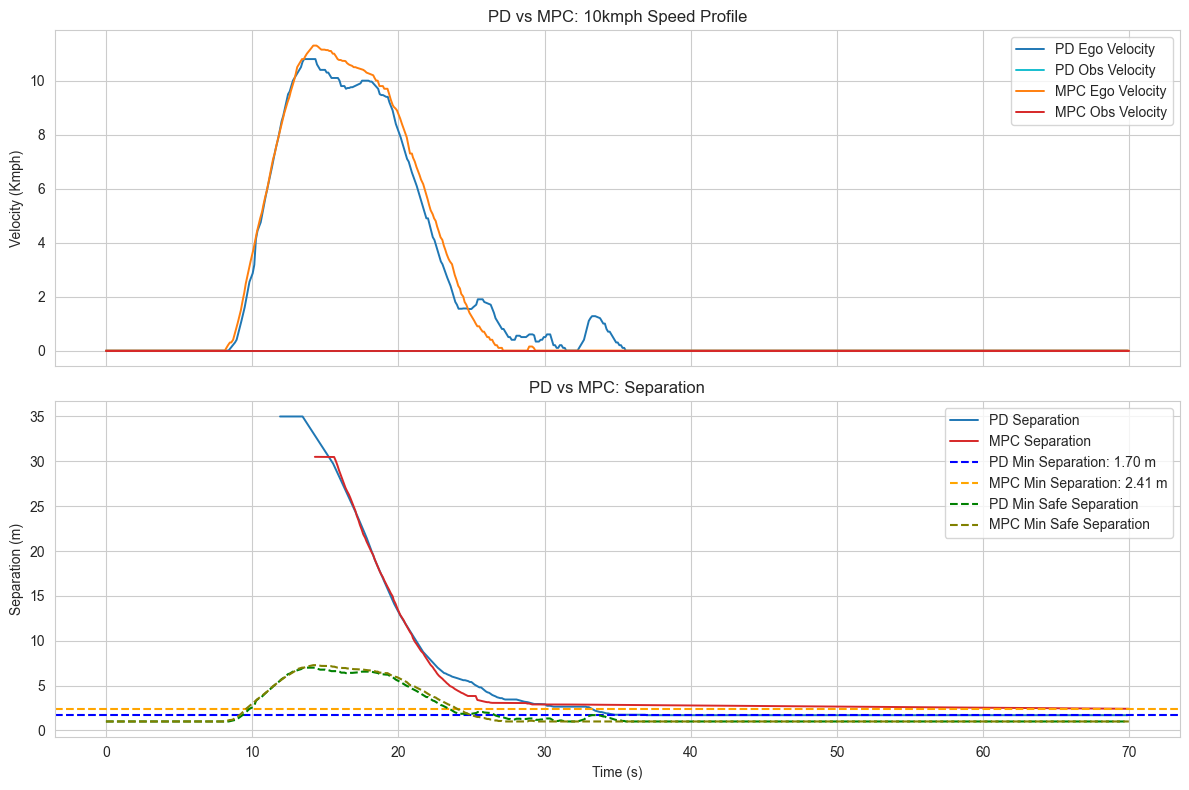

In [221]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, MPC_file_name))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:cyan", linewidth=1.4)
ax[0].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:orange", linewidth=1.4)
ax[0].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:red", linewidth=1.4)
ax[0].set_ylabel("Velocity (Kmph)")
ax[0].legend(loc="best")
ax[0].grid(True)
ax[0].set_title("PD vs MPC: 10kmph Speed Profile")


# Plot 2: Separation for PD and MPC
ax[1].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:red", linewidth=1.4)
ax[1].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1].axhline(y=minimum_separation_mpc, color='orange', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1].set_ylabel("Separation (m)")
ax[1].set_xlabel("Time (s)")
ax[1].legend(loc="best")
ax[1].grid(True)
ax[1].set_title("PD vs MPC: Separation")

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
legends = ax[1].get_legend_handles_labels()
by_label = dict(zip(legends[1], legends[0]))
ax[1].legend(by_label.values(), by_label.keys(), loc="best")

plt.tight_layout()
plt.show() 

PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Time_1s', 'Ego_Acceleration_raw(m/s^2)', 'Obs_Acceleration_raw(m/s^2)', 'Ego_Acceleration(m/s^2)', 'Obs_Acceleration(m/s^2)', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Acceleration_clean', 'Obs_Acceleration_clean', 'Ego_Position_clean', 'Obs_Position_clean']


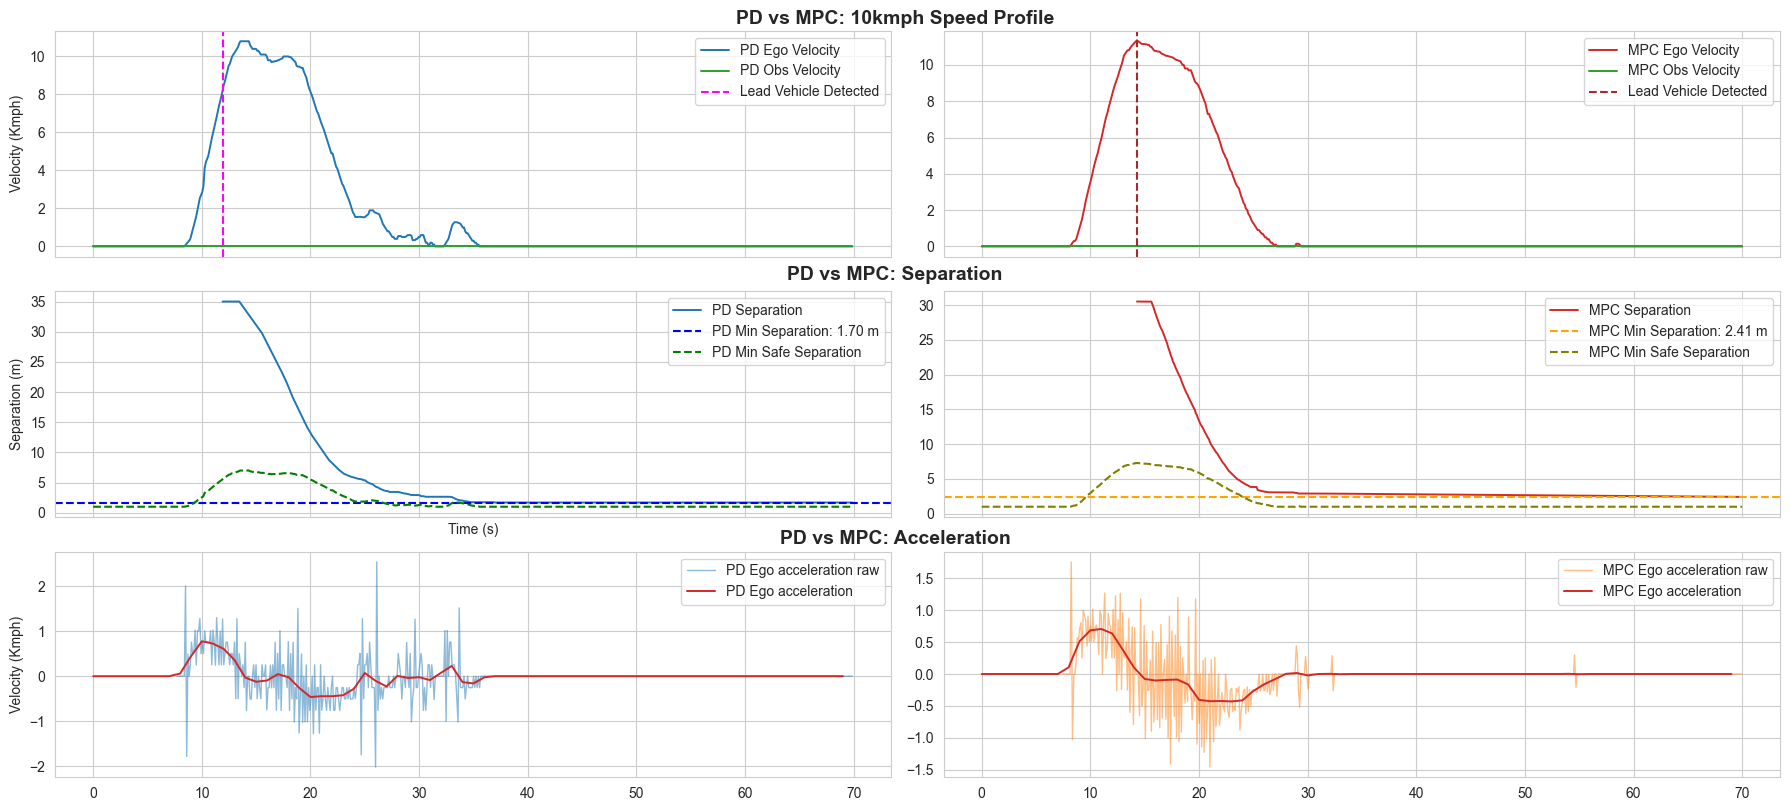

In [222]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, MPC_file_name))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
x_col_1 = "Time_1s" # Time in 1 second
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"
ego_acc_raw = "Ego_Acceleration_raw(m/s^2)"
ego_acc_clean = "Ego_Acceleration(m/s^2)"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(3, 2, figsize=(18, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0][0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0][0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:red", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:green", linewidth=1.4)
ax[0][0].set_ylabel("Velocity (Kmph)")
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best")
ax[0][0].grid(True)
ax[0][1].grid(True)
# ax[0][0].set_title("PD vs MPC: 10kmph Speed Profile")

# Plot the detection line at the point where the obstacle is detected (when separation starts decreasing from a large value)
detection_time_pd = pdc_df[pdc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
detection_time_mpc = mpc_df[mpc_df[sep_col] < 100][x_col].iloc[0]  # Assuming detection happens when separation drops below 100m
ax[0][0].axvline(x=detection_time_pd, color='magenta', linestyle='--', label= 'Lead Vehicle Detected')
ax[0][1].axvline(x=detection_time_mpc, color='brown', linestyle='--', label='Lead Vehicle Detected')
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best") 

# Plot 2: Separation for PD and MPC
ax[1][0].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1][1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:red", linewidth=1.4)
ax[1][0].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1][1].axhline(y=minimum_separation_mpc, color='orange', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1][0].set_ylabel("Separation (m)")
ax[1][0].set_xlabel("Time (s)")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")
ax[1][0].grid(True)
ax[1][1].grid(True)
# ax[1][0].set_title("PD vs MPC: Separation")

# Plot 3 : Acceleration for PD and MPC
ax[2][0].plot(pdc_df[x_col], pdc_df[ego_acc_raw], label="PD Ego acceleration raw", color="tab:blue", linewidth=1, alpha=0.5)
ax[2][0].plot(pdc_df[x_col_1], pdc_df[ego_acc_clean], label="PD Ego acceleration ", color="tab:red", linewidth=1.4)
ax[2][1].plot(mpc_df[x_col], mpc_df[ego_acc_raw], label="MPC Ego acceleration raw", color="tab:orange", linewidth=1 , alpha=0.5)
ax[2][1].plot(mpc_df[x_col_1], mpc_df[ego_acc_clean], label="MPC Ego acceleration", color="tab:red", linewidth=1.4)
ax[2][0].set_ylabel("Velocity (Kmph)")
ax[2][0].legend(loc="best")
ax[2][1].legend(loc="best")
ax[2][0].grid(True)
ax[2][1].grid(True)

fig.subplots_adjust(hspace=1)  # Reasonable spacing between rows
plt.tight_layout()

fig.text(0.5, 0.99, "PD vs MPC: 10kmph Speed Profile", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.67, "PD vs MPC: Separation", ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.34, "PD vs MPC: Acceleration", ha='center', fontsize=14, weight='bold')

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1][0].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1][1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")


plt.tight_layout()
plt.show() 

In [223]:
import numpy as np
import pandas as pd
from scipy import signal
import os
import re


def extract_file_info(filename):
    """Extract speed and case number from filename"""
    match = re.search(r'(\d+kph)_CS(\d+)', filename)
    if match:
        return match.group(1), int(match.group(2))
    return None, None

def calculate_metrics(df, controller_name="Controller"):
    """Calculate all publication-ready metrics including overshoot/undershoot"""
    sep_col = "Separation_clean"
    ego_vel_col = "Ego_Velocity_clean"
    obs_vel_col = "Obs_Velocity_clean"
    ego_acc_raw = "Ego_Acceleration_raw(m/s^2)"
    ego_acc_clean = "Ego_Acceleration(m/s^2)"
    time_col = "Time(s)"

    # 1. MINIMUM SEPARATION
    min_sep = df[sep_col].min()
    mean_sep = df[sep_col].mean()
    std_sep = df[sep_col].std()

    # 2. RMS ACCELERATION
    rms_acc = np.sqrt(np.mean(df[ego_acc_clean]**2))

    # 3. JERK
    acc_smooth = df[ego_acc_clean].values
    dt = np.diff(df[time_col].values)
    dt = np.median(dt[dt > 0])
    jerk = np.diff(acc_smooth) / dt
    mean_jerk = np.mean(np.abs(jerk))
    max_jerk = np.max(np.abs(jerk))

    # 4. NOISE SENSITIVITY
    acc_raw = df[ego_acc_raw].values
    noise_std = np.std(acc_raw - acc_smooth)
    noise_ratio = noise_std / (np.std(acc_smooth) + 1e-6)

    # 5. STEADY STATE ERROR
    sep_rate_of_change = np.abs(np.diff(df[sep_col].values))
    sep_rate_smooth = signal.savgol_filter(sep_rate_of_change,
                                           window_length=min(11, len(sep_rate_of_change)//2 if len(sep_rate_of_change)//2 % 2 == 1 else len(sep_rate_of_change)//2 + 1),
                                           polyorder=2)
    threshold = np.percentile(sep_rate_smooth, 25)
    steady_state_idx = sep_rate_smooth < threshold

    if np.sum(steady_state_idx) > 0:
        steady_state_vel_error = np.abs(df[ego_vel_col].values[1:][steady_state_idx] -
                                       df[obs_vel_col].values[1:][steady_state_idx])
        mean_ss_error = np.mean(steady_state_vel_error)
        std_ss_error = np.std(steady_state_vel_error)
    else:
        mean_ss_error = 0
        std_ss_error = 0

    # 6. OVERSHOOT/UNDERSHOOT %
    ego_vel = df[ego_vel_col].values
    obs_vel = df[obs_vel_col].values
    vel_error = ego_vel - obs_vel

    # Overshoot: ego faster than obstacle
    overshoot_idx = vel_error > 0
    if np.sum(overshoot_idx) > 0:
        overshoot_pct = (vel_error[overshoot_idx] / (obs_vel[overshoot_idx] + 1e-6)) * 100
        max_overshoot_pct = np.max(overshoot_pct)
        mean_overshoot_pct = np.mean(overshoot_pct)
    else:
        max_overshoot_pct = 0
        mean_overshoot_pct = 0

    # Undershoot: ego slower than obstacle
    undershoot_idx = vel_error < 0
    if np.sum(undershoot_idx) > 0:
        undershoot_pct = (np.abs(vel_error[undershoot_idx]) / (obs_vel[undershoot_idx] + 1e-6)) * 100
        max_undershoot_pct = np.max(undershoot_pct)
        mean_undershoot_pct = np.mean(undershoot_pct)
    else:
        max_undershoot_pct = 0
        mean_undershoot_pct = 0

    return {
        'Controller': controller_name,
        'Min Separation (m)': f"{min_sep:.3f}",
        'Mean Separation (m)': f"{mean_sep:.3f}",
        'Std Separation (m)': f"{std_sep:.3f}",
        'RMS Acceleration (m/s^2)': f"{rms_acc:.4f}",
        'Mean Jerk (m/s^3)': f"{mean_jerk:.4f}",
        'Max Jerk (m/s^3)': f"{max_jerk:.4f}",
        'Noise Std Dev (m/s^2)': f"{noise_std:.4f}",
        'Noise to Signal Ratio': f"{noise_ratio:.4f}",
        'Mean SS Velocity Error (m/s)': f"{mean_ss_error:.4f}",
        'Std SS Velocity Error (m/s)': f"{std_ss_error:.4f}",
        'Max Overshoot (%)': f"{max_overshoot_pct:.2f}",
        'Mean Overshoot (%)': f"{mean_overshoot_pct:.2f}",
        'Max Undershoot (%)': f"{max_undershoot_pct:.2f}",
        'Mean Undershoot (%)': f"{mean_undershoot_pct:.2f}",
    }

# Get all files
pdc_files = sorted([f for f in os.listdir(internal_PDC_CDP_data_dir) if f.endswith('.csv')])
mpc_files = sorted([f for f in os.listdir(internal_MPC_CDP_data_dir) if f.endswith('.csv')])

# Organize by speed and case
pdc_by_test = {}
mpc_by_test = {}
for f in pdc_files:
    speed, case = extract_file_info(f)
    if speed:
        pdc_by_test[(speed, case)] = f
for f in mpc_files:
    speed, case = extract_file_info(f)
    if speed:
        mpc_by_test[(speed, case)] = f

print("="*130)
print("PUBLICATION-READY METRICS: PD vs MPC COMPARISON (WITH OVERSHOOT/UNDERSHOOT)")
print("="*130)

all_metrics = []
speeds = sorted(set([k[0] for k in pdc_by_test.keys()] + [k[0] for k in mpc_by_test.keys()]))

for speed in speeds:
    print(f"\n{'='*50}")
    print(f"{speed.upper()} SPEED PROFILE")
    print('='*50)

    pdc_cases = sorted([k[1] for k in pdc_by_test.keys() if k[0] == speed])
    mpc_cases = sorted([k[1] for k in mpc_by_test.keys() if k[0] == speed])
    common_cases = sorted(set(pdc_cases) & set(mpc_cases))

    for case_num in common_cases:
        pdc_file = pdc_by_test[(speed, case_num)]
        mpc_file = mpc_by_test[(speed, case_num)]

        print(f"\nTest Case CS{case_num}: {pdc_file} vs {mpc_file}")

        pdc_df = pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, pdc_file))
        mpc_df = pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, mpc_file))

        pdc_metrics = calculate_metrics(pdc_df, f"PD-{speed}-CS{case_num}")
        mpc_metrics = calculate_metrics(mpc_df, f"MPC-{speed}-CS{case_num}")

        pdc_metrics['Speed'] = speed
        mpc_metrics['Speed'] = speed
        pdc_metrics['Type'] = 'PD'
        mpc_metrics['Type'] = 'MPC'
        pdc_metrics['Case'] = f"CS{case_num}"
        mpc_metrics['Case'] = f"CS{case_num}"

        print("\nPD Controller:")
        for key, val in pdc_metrics.items():
            if key != 'Controller':
                print(f"  {key}: {val}")

        print("\nMPC Controller:")
        for key, val in mpc_metrics.items():
            if key != 'Controller':
                print(f"  {key}: {val}")

        all_metrics.append(pdc_metrics)
        all_metrics.append(mpc_metrics)

print("\n" + "="*130)
print("SUMMARY TABLE - ALL METRICS WITH OVERSHOOT/UNDERSHOOT")
print("="*130)
metrics_df = pd.DataFrame(all_metrics)
print(metrics_df.to_string(index=False))

metrics_df.to_csv('Metrics_Comparison.csv', index=False)
print(f"\n[SUCCESS] Metrics saved to: Metrics_Comparison.csv")
print(f"[SUCCESS] Total test cases compared: {len(all_metrics)//2}")
print(f"\nNew columns added:")
print(f"  - Max Overshoot (%): Maximum % ego exceeds target velocity")
print(f"  - Mean Overshoot (%): Average % when ego is faster than target")
print(f"  - Max Undershoot (%): Maximum % ego falls below target velocity")
print(f"  - Mean Undershoot (%): Average % when ego is slower than target")




PUBLICATION-READY METRICS: PD vs MPC COMPARISON (WITH OVERSHOOT/UNDERSHOOT)

10KPH SPEED PROFILE

Test Case CS1: Data_Mar27_PD_10kph_CS1.csv vs Data_Mar27_MPC_10kph_CS1.csv

PD Controller:
  Min Separation (m): 1.700
  Mean Separation (m): 6.025
  Std Separation (m): 9.072
  RMS Acceleration (m/s^2): 0.2181
  Mean Jerk (m/s^3): 0.0709
  Max Jerk (m/s^3): 3.5694
  Noise Std Dev (m/s^2): nan
  Noise to Signal Ratio: nan
  Mean SS Velocity Error (m/s): 0.0000
  Std SS Velocity Error (m/s): 0.0000
  Max Overshoot (%): 1080000019.07
  Mean Overshoot (%): 462711093.28
  Max Undershoot (%): 0.00
  Mean Undershoot (%): 0.00
  Speed: 10kph
  Type: PD
  Case: CS1

MPC Controller:
  Min Separation (m): 2.884
  Mean Separation (m): 5.938
  Std Separation (m): 7.046
  RMS Acceleration (m/s^2): 0.2131
  Mean Jerk (m/s^3): 0.0453
  Max Jerk (m/s^3): 3.7143
  Noise Std Dev (m/s^2): nan
  Noise to Signal Ratio: nan
  Mean SS Velocity Error (m/s): 0.0000
  Std SS Velocity Error (m/s): 0.0000
  Max Overs

# Visualization: Metrics Comparison Plots

In [224]:
import seaborn as sns
sns.set_style("whitegrid")

# Prepare numeric metrics for visualization
all_metrics_numeric = []
for speed in speeds:
    pdc_cases = sorted([k[1] for k in pdc_by_test.keys() if k[0] == speed])
    mpc_cases = sorted([k[1] for k in mpc_by_test.keys() if k[0] == speed])
    common_cases = sorted(set(pdc_cases) & set(mpc_cases))

    for case_num in common_cases:
        pdc_file = pdc_by_test[(speed, case_num)]
        mpc_file = mpc_by_test[(speed, case_num)]
        pdc_df = pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, pdc_file))
        mpc_df = pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, mpc_file))

        for df, controller_type in [(pdc_df, 'PD'), (mpc_df, 'MPC')]:
            sep_col, ego_vel_col, obs_vel_col = "Separation_clean", "Ego_Velocity_clean", "Obs_Velocity_clean"
            ego_acc_clean, time_col = "Ego_Acceleration(m/s^2)", "Time(s)"

            min_sep = df[sep_col].min()
            rms_acc = np.sqrt(np.mean(df[ego_acc_clean]**2))
            acc_smooth = df[ego_acc_clean].values
            dt = np.median(np.diff(df[time_col].values))
            mean_jerk = np.mean(np.abs(np.diff(acc_smooth) / dt))

            ego_vel = df[ego_vel_col].values
            obs_vel = df[obs_vel_col].values
            vel_error = ego_vel - obs_vel

            overshoot_idx = vel_error > 0
            max_overshoot = np.max((vel_error[overshoot_idx] / (obs_vel[overshoot_idx] + 1e-6)) * 100) if np.sum(overshoot_idx) > 0 else 0

            undershoot_idx = vel_error < 0
            max_undershoot = np.max((np.abs(vel_error[undershoot_idx]) / (obs_vel[undershoot_idx] + 1e-6)) * 100) if np.sum(undershoot_idx) > 0 else 0

            all_metrics_numeric.append({
                'Speed': speed,
                'Type': controller_type,
                'Case': f"CS{case_num}",
                'Min Separation': min_sep,
                'RMS Acceleration': rms_acc,
                'Mean Jerk': mean_jerk,
                'Max Overshoot': max_overshoot,
                'Max Undershoot': max_undershoot,
            })

metrics_plot_df = pd.DataFrame(all_metrics_numeric)
print(f"Prepared {len(metrics_plot_df)} metric records for visualization")


Prepared 12 metric records for visualization


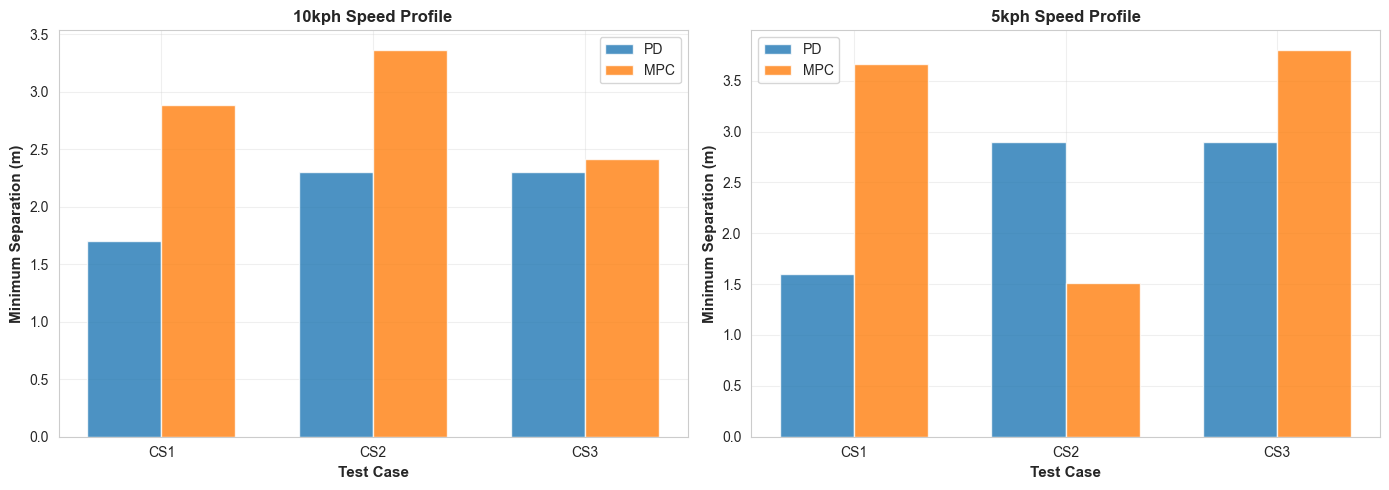

Plot 1: Separation Comparison - Complete


In [225]:
# PLOT 1: Separation Metrics Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, speed in enumerate(sorted(metrics_plot_df['Speed'].unique())):
    speed_data = metrics_plot_df[metrics_plot_df['Speed'] == speed]
    pd_data = speed_data[speed_data['Type'] == 'PD'].sort_values('Case')
    mpc_data = speed_data[speed_data['Type'] == 'MPC'].sort_values('Case')

    cases = pd_data['Case'].values
    x = np.arange(len(cases))
    width = 0.35

    axes[idx].bar(x - width/2, pd_data['Min Separation'].values, width, label='PD', alpha=0.8, color='#1f77b4')
    axes[idx].bar(x + width/2, mpc_data['Min Separation'].values, width, label='MPC', alpha=0.8, color='#ff7f0e')

    axes[idx].set_xlabel('Test Case', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Minimum Separation (m)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{speed} Speed Profile', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(cases)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Plot 1: Separation Comparison - Complete")


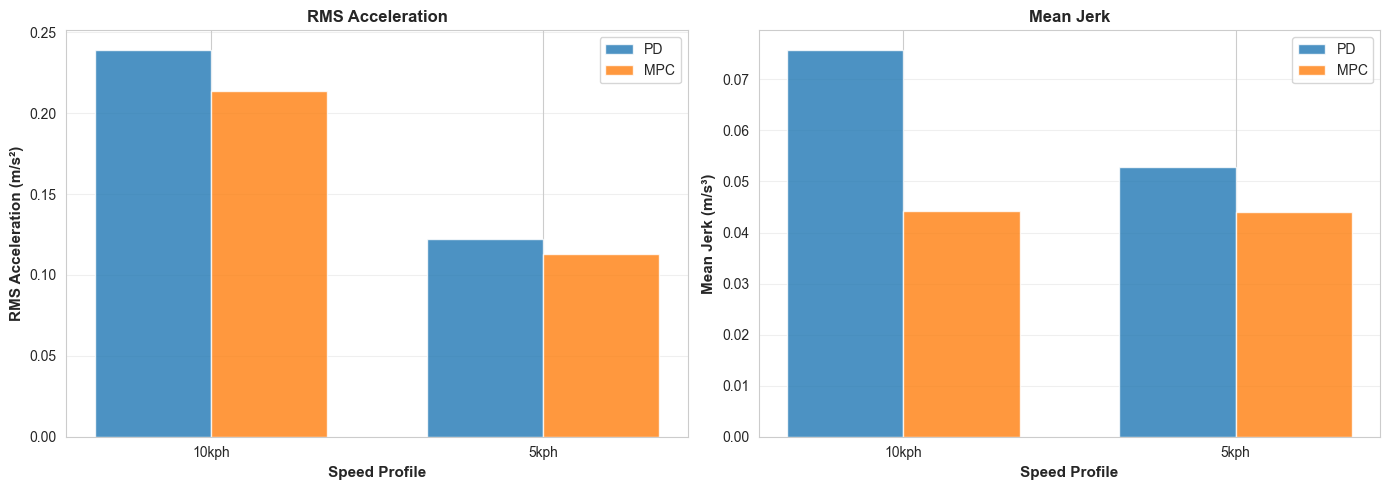

Plot 2: Smoothness Metrics - Complete


In [226]:
# PLOT 2: Acceleration Smoothness Metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, metric in enumerate(['RMS Acceleration', 'Mean Jerk']):
    speed_groups = sorted(metrics_plot_df['Speed'].unique())
    pd_means = [metrics_plot_df[(metrics_plot_df['Speed'] == speed) & (metrics_plot_df['Type'] == 'PD')][metric].mean() for speed in speed_groups]
    mpc_means = [metrics_plot_df[(metrics_plot_df['Speed'] == speed) & (metrics_plot_df['Type'] == 'MPC')][metric].mean() for speed in speed_groups]

    x = np.arange(len(speed_groups))
    width = 0.35

    axes[idx].bar(x - width/2, pd_means, width, label='PD', alpha=0.8, color='#1f77b4')
    axes[idx].bar(x + width/2, mpc_means, width, label='MPC', alpha=0.8, color='#ff7f0e')

    axes[idx].set_xlabel('Speed Profile', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(metric + (' (m/s²)' if 'Accel' in metric else ' (m/s³)'), fontsize=11, fontweight='bold')
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(speed_groups)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("Plot 2: Smoothness Metrics - Complete")


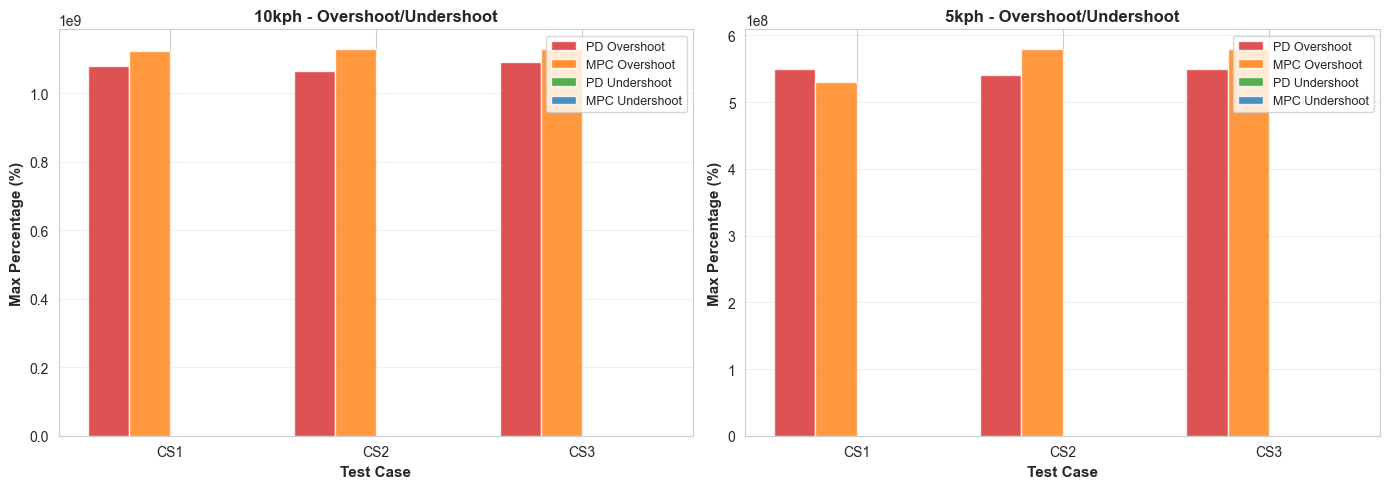

Plot 3: Overshoot/Undershoot - Complete


In [227]:
# PLOT 3: Overshoot/Undershoot Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, speed in enumerate(sorted(metrics_plot_df['Speed'].unique())):
    speed_data = metrics_plot_df[metrics_plot_df['Speed'] == speed]
    pd_data = speed_data[speed_data['Type'] == 'PD'].sort_values('Case')
    mpc_data = speed_data[speed_data['Type'] == 'MPC'].sort_values('Case')

    cases = pd_data['Case'].values
    x = np.arange(len(cases))
    width = 0.2

    axes[idx].bar(x - width*1.5, pd_data['Max Overshoot'].values, width, label='PD Overshoot', alpha=0.8, color='#d62728')
    axes[idx].bar(x - width*0.5, mpc_data['Max Overshoot'].values, width, label='MPC Overshoot', alpha=0.8, color='#ff7f0e')
    axes[idx].bar(x + width*0.5, pd_data['Max Undershoot'].values, width, label='PD Undershoot', alpha=0.8, color='#2ca02c')
    axes[idx].bar(x + width*1.5, mpc_data['Max Undershoot'].values, width, label='MPC Undershoot', alpha=0.8, color='#1f77b4')

    axes[idx].set_xlabel('Test Case', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Max Percentage (%)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{speed} - Overshoot/Undershoot', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(cases)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("Plot 3: Overshoot/Undershoot - Complete")


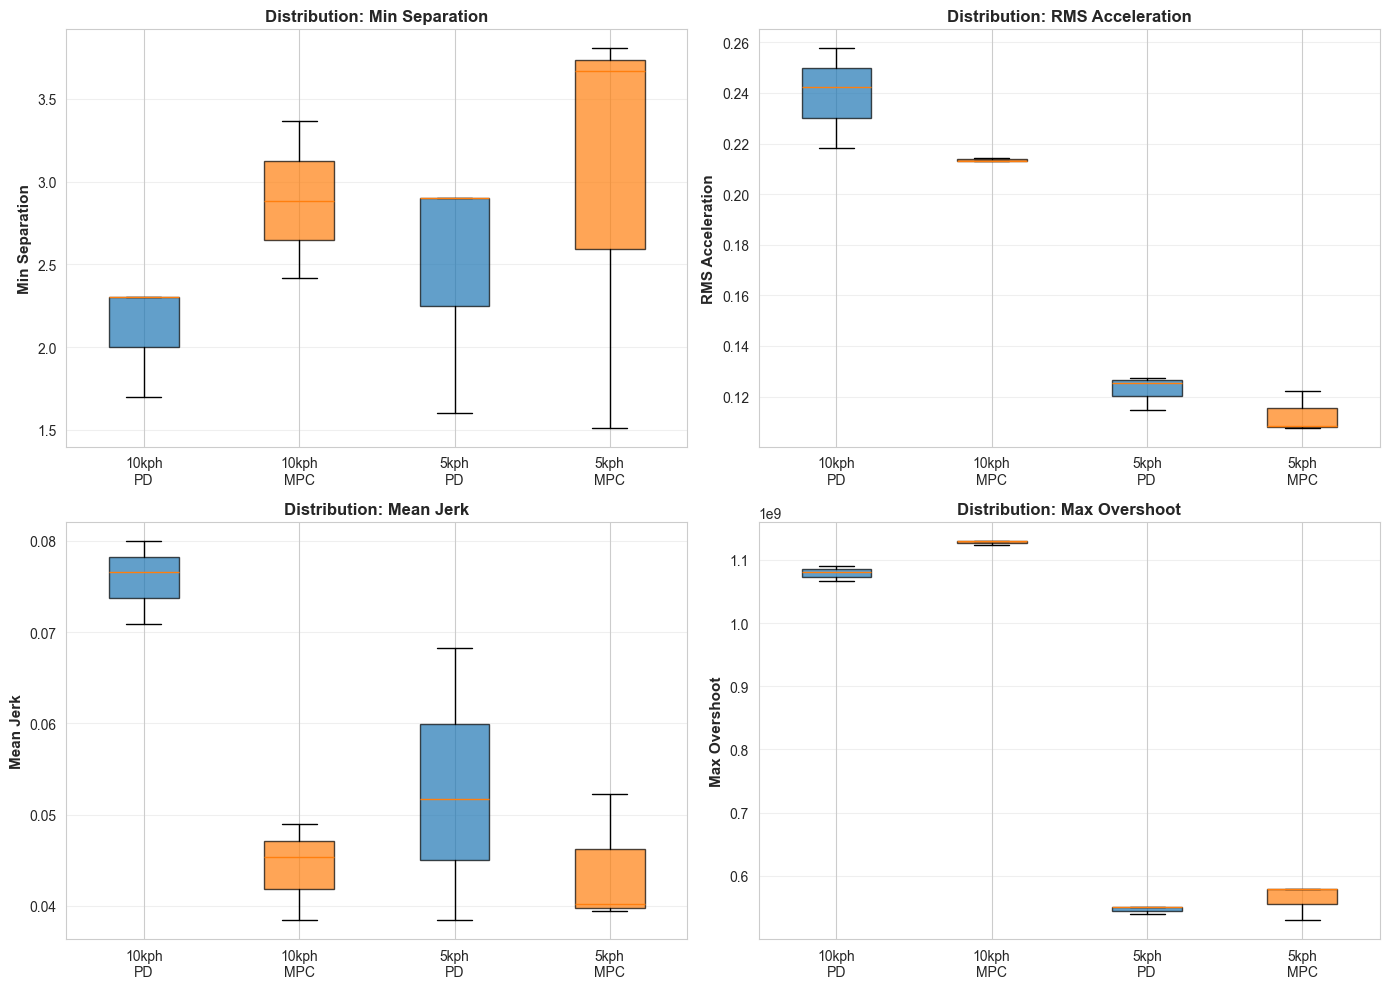

Plot 4: Statistical Distribution Box Plots - Complete


In [228]:
# PLOT 4: Box Plots for Statistical Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = ['Min Separation', 'RMS Acceleration', 'Mean Jerk', 'Max Overshoot']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]

    plot_data = []
    labels = []
    for speed in sorted(metrics_plot_df['Speed'].unique()):
        for controller in ['PD', 'MPC']:
            data = metrics_plot_df[(metrics_plot_df['Speed'] == speed) & (metrics_plot_df['Type'] == controller)][metric].values
            plot_data.append(data)
            labels.append(f"{speed}\n{controller}")

    bp = ax.boxplot(plot_data, tick_labels=labels, patch_artist=True)

    colors = ['#1f77b4', '#ff7f0e'] * len(sorted(metrics_plot_df['Speed'].unique()))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'Distribution: {metric}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("Plot 4: Statistical Distribution Box Plots - Complete")


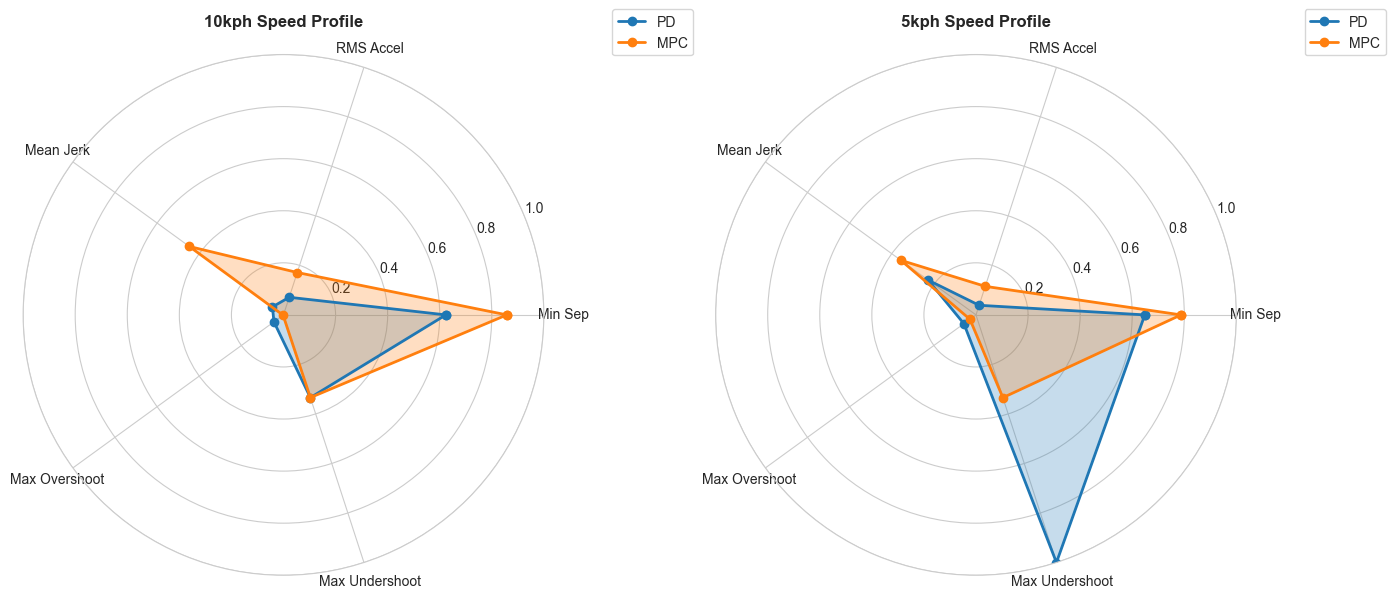

Plot 5: Performance Radar Chart - Complete

All visualization plots generated successfully!


In [229]:
# PLOT 5: Overall Performance Radar Chart
from math import pi

fig = plt.figure(figsize=(14, 7))
speeds = sorted(metrics_plot_df['Speed'].unique())

for speed_idx, speed in enumerate(speeds):
    speed_data = metrics_plot_df[metrics_plot_df['Speed'] == speed]

    categories = ['Min Sep', 'RMS Accel', 'Mean Jerk', 'Max Overshoot', 'Max Undershoot']

    pd_avg = [
        speed_data[speed_data['Type'] == 'PD']['Min Separation'].mean() / speed_data['Min Separation'].max(),
        1 - (speed_data[speed_data['Type'] == 'PD']['RMS Acceleration'].mean() / speed_data['RMS Acceleration'].max()),
        1 - (speed_data[speed_data['Type'] == 'PD']['Mean Jerk'].mean() / speed_data['Mean Jerk'].max()),
        1 - (speed_data[speed_data['Type'] == 'PD']['Max Overshoot'].mean() / (speed_data['Max Overshoot'].max() + 0.1)),
        1 - (speed_data[speed_data['Type'] == 'PD']['Max Undershoot'].mean() / (speed_data['Max Undershoot'].max() + 0.1))
    ]

    mpc_avg = [
        speed_data[speed_data['Type'] == 'MPC']['Min Separation'].mean() / speed_data['Min Separation'].max(),
        1 - (speed_data[speed_data['Type'] == 'MPC']['RMS Acceleration'].mean() / speed_data['RMS Acceleration'].max()),
        1 - (speed_data[speed_data['Type'] == 'MPC']['Mean Jerk'].mean() / speed_data['Mean Jerk'].max()),
        1 - (speed_data[speed_data['Type'] == 'MPC']['Max Overshoot'].mean() / (speed_data['Max Overshoot'].max() + 0.1)),
        1 - (speed_data[speed_data['Type'] == 'MPC']['Max Undershoot'].mean() / (speed_data['Max Undershoot'].max() + 0.1))
    ]

    angles = [n / len(categories) * 2 * pi for n in range(len(categories))]
    pd_avg += pd_avg[:1]
    mpc_avg += mpc_avg[:1]
    angles += angles[:1]

    ax = plt.subplot(1, 2, speed_idx + 1, projection='polar')
    ax.plot(angles, pd_avg, 'o-', linewidth=2, label='PD', color='#1f77b4')
    ax.fill(angles, pd_avg, alpha=0.25, color='#1f77b4')
    ax.plot(angles, mpc_avg, 'o-', linewidth=2, label='MPC', color='#ff7f0e')
    ax.fill(angles, mpc_avg, alpha=0.25, color='#ff7f0e')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(f'{speed} Speed Profile', fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.grid(True)

plt.tight_layout()
plt.show()
print("Plot 5: Performance Radar Chart - Complete")
print("\nAll visualization plots generated successfully!")
